In [2]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# File system manangement
import os
import gc
from sklearn.model_selection import train_test_split

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [21]:
train = pd.read_csv("../data/X_train.csv")
test = pd.read_csv("../data/X_test.csv")


In [24]:
print(test.columns)

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'relatives', 'not_alone', 'Deck', 'Title', 'Age_Class',
       'Fare_Per_Person'],
      dtype='object')


In [25]:
test.drop(['PassengerId'], axis=1, inplace=True)


In [4]:
import tqdm



unique_samples = []
unique_count = np.zeros_like(test)
for feature in tqdm(range(test.shape[1])):
    _, index_, count_ = np.unique(test[:, feature], return_counts=True, return_index=True)
    unique_count[index_[count_ == 1], feature] += 1

# Samples which have unique values are real the others are fake
real_samples_indexes = np.argwhere(np.sum(unique_count, axis=1) > 0)[:, 0]
synthetic_samples_indexes = np.argwhere(np.sum(unique_count, axis=1) == 0)[:, 0]

print(len(real_samples_indexes))
print(len(synthetic_samples_indexes))

TypeError: 'module' object is not callable

# detect_synthetic_samples

Detect which samples (rows) in a dataset are likely real vs synthetic/fake based on unique values in each feature.

In [5]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def detect_synthetic_samples(df, id_column=None, show_progress=True):
    """
    Detect real and synthetic samples based on unique values in features.

    Parameters
    ----------
    df : pd.DataFrame or np.ndarray
        Input dataset.
    id_column : str, optional
        Column to drop (like ID codes). Default is None.
    show_progress : bool
        Whether to display a progress bar when processing features. Default is True.

    Returns
    -------
    real_indices : np.ndarray
        Indices of likely real samples.
    synthetic_indices : np.ndarray
        Indices of likely synthetic samples.
    """
    
    # Convert DataFrame to NumPy array and drop ID column if specified
    if isinstance(df, pd.DataFrame):
        if id_column and id_column in df.columns:
            df = df.drop(columns=id_column)
        data = df.values
    else:
        data = df.copy()
    
    # Array to count unique values per sample
    unique_count = np.zeros_like(data, dtype=int)
    
    # Loop over each feature
    features = range(data.shape[1])
    if show_progress:
        features = tqdm(features, desc="Processing features")
    
    for col in features:
        # Find unique values, their first index, and counts
        _, indices, counts = np.unique(data[:, col], return_index=True, return_counts=True)
        # Mark positions where the value is unique
        unique_count[indices[counts == 1], col] = 1
    
    # Samples with at least one unique value are considered real
    row_unique_sum = np.sum(unique_count, axis=1)
    real_indices = np.where(row_unique_sum > 0)[0]
    synthetic_indices = np.where(row_unique_sum == 0)[0]
    
    return real_indices, synthetic_indices


In [6]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,relatives,not_alone,Deck,Title,Age_Class,Fare_Per_Person
0,3,0,2,1,0,0,0,1,0,8,1,6,0
1,1,1,5,1,0,3,1,1,0,3,3,5,1
2,3,1,3,0,0,0,0,0,1,8,2,9,0
3,1,1,5,1,0,3,0,1,0,3,3,5,1
4,3,0,5,0,0,1,0,0,1,8,1,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,0,3,0,0,1,0,0,1,8,5,6,1
887,1,1,2,0,0,2,0,0,1,2,2,2,2
888,3,1,3,1,2,2,0,3,0,8,2,9,0
889,1,0,3,0,0,2,1,0,1,3,1,3,2


In [7]:
train_real_idx, train_synthetic_idx = detect_synthetic_samples(train, id_column="PassengerId")


test_real_idx, test_synthetic_idx = detect_synthetic_samples(test, id_column="PassengerId")

print("Real samples in train:", len(train_real_idx))
print("Synthetic samples train:", len(train_synthetic_idx))

print("Real samples in test:", len(test_real_idx))
print("Synthetic samples test:", len(test_synthetic_idx))

Processing features: 100%|██████████| 13/13 [00:00<00:00, 2345.40it/s]

Real samples in train: 2
Synthetic samples train: 889
Real samples in test: 4
Synthetic samples test: 414


For each synthetic sample:

- Compares it to all real samples feature by feature.

- Identifies features that match exactly one real sample.

- Marks real samples that match at least one unique feature as potential “generators”.

- Returns a list of sets, each set containing the indices of real samples that could have generated the corresponding synthetic sample.

In [8]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def find_generators_for_synthetic_samples(df, real_indices, synthetic_indices, max_samples=20000, show_progress=True):
    """
    For each synthetic sample, find potential real sample(s) that could have generated it.

    Parameters
    ----------
    df : pd.DataFrame or np.ndarray
        Full dataset containing both real and synthetic samples.
    real_indices : np.ndarray
        Indices of real samples in the dataset.
    synthetic_indices : np.ndarray
        Indices of synthetic samples in the dataset.
    max_samples : int
        Maximum number of synthetic samples to process (for speed). Default is 20000.
    show_progress : bool
        Whether to show a progress bar. Default is True.

    Returns
    -------
    generator_for_each_synthetic_sample : list of sets
        Each element is a set of indices of real samples that could have generated the synthetic sample.
    """
    # Ensure we use NumPy array for faster computation
    if isinstance(df, pd.DataFrame):
        data = df.values
    else:
        data = df.copy()
    
    # Subset of only real samples
    df_real = data[real_indices]
    
    generator_for_each_synthetic_sample = []

    # Limit the number of synthetic samples processed
    synthetic_to_process = synthetic_indices[:max_samples]
    
    iterator = synthetic_to_process
    if show_progress:
        iterator = tqdm(iterator, desc="Processing synthetic samples")
    
    for cur_idx in iterator:
        synthetic_sample = data[cur_idx]
        
        # Compare with all real samples
        potential_generators = df_real == synthetic_sample
        
        # Features that match uniquely in real samples
        features_mask = np.sum(potential_generators, axis=0) == 1
        
        # Real samples matching at least one uniquely matching feature
        verified_mask = np.any(potential_generators[:, features_mask], axis=1)
        
        # Convert to actual indices in the original dataset
        verified_generators = real_indices[np.where(verified_mask)[0]]
        
        # Store as a set
        generator_for_each_synthetic_sample.append(set(verified_generators))
    
    return generator_for_each_synthetic_sample


In [9]:
# Assume you already have:
# df_test -> the dataset
# real_idx -> indices of real samples (from detect_synthetic_samples)
# synthetic_idx -> indices of synthetic samples

generators = find_generators_for_synthetic_samples(
    df=test,
    real_indices=test_real_idx,
    synthetic_indices=test_synthetic_idx,
    max_samples=20000,
    show_progress=True
)

# generators[i] is a set of real sample indices that could have generated synthetic sample i
print("Example for first synthetic sample:", generators[0])


Processing synthetic samples: 100%|██████████| 414/414 [00:00<00:00, 45419.73it/s]

Example for first synthetic sample: {140}




After collecting the "verified generators" for each fake sample, finding the Public/Private LB split is no more than a few set operations.


In [10]:
# this code need to be fixed based on the above code


# public_LB = generator_for_each_synthetic_sample[0]
# for x in tqdm(generator_for_each_synthetic_sample):
#     if public_LB.intersection(x):
#         public_LB = public_LB.union(x)

# private_LB = generator_for_each_synthetic_sample[1]
# for x in tqdm(generator_for_each_synthetic_sample):
#     if private_LB.intersection(x):
#         private_LB = private_LB.union(x)
        
# print(len(public_LB))
# print(len(private_LB))


# np.save('public_LB', list(public_LB))
# np.save('private_LB', list(private_LB))
# np.save('synthetic_samples_indexes', list(synthetic_samples_indexes))

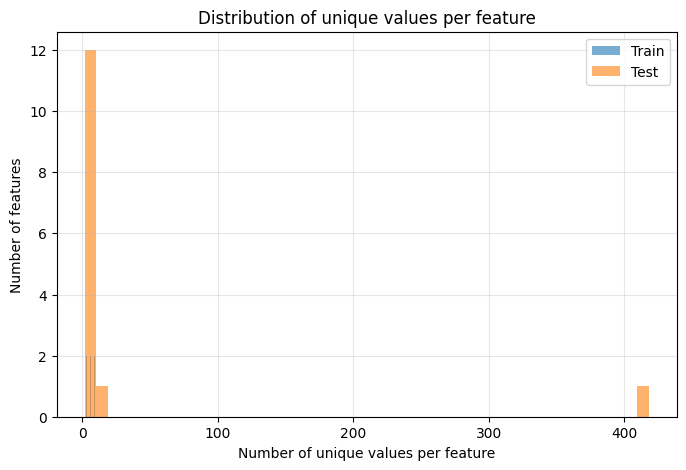

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_unique_values_distribution(X_train, X_test, bins=50):
    # Number of unique values per feature
    train_uniques = X_train.nunique().values
    test_uniques = X_test.nunique().values

    plt.figure(figsize=(8, 5))
    plt.hist(train_uniques, bins=bins, alpha=0.6, label="Train")
    plt.hist(test_uniques, bins=bins, alpha=0.6, label="Test")

    plt.xlabel("Number of unique values per feature")
    plt.ylabel("Number of features")
    plt.title("Distribution of unique values per feature")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_unique_values_distribution(train, test)




# Adversarial Validation for Feature Discovery

Sometimes the train and test datasets come from slightly different distributions. This is called dataset shift (a known problem in machine learning related to the Covariate Shift concept).

Adversarial validation tries to detect these differences.

| Adversarial AUC | Meaning                   |
| --------------- | ------------------------- |
| 0.5             | train = test distribution |
| 0.6             | small shift               |
| 0.7             | noticeable shift          |
| 0.8+            | strong dataset shift      |


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import pandas as pd
import numpy as np


def adversarial_validation(train, test):

    train_adv = train.copy()
    test_adv = test.copy()

    train_adv["adv_target"] = 0
    test_adv["adv_target"] = 1

    full = pd.concat([train_adv, test_adv], axis=0).reset_index(drop=True)

    y = full["adv_target"]
    X = full.drop(columns=["adv_target"])

    X = pd.get_dummies(X)

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for tr, val in skf.split(X, y):

        model.fit(X.iloc[tr], y.iloc[tr])
        preds = model.predict_proba(X.iloc[val])[:,1]

        scores.append(roc_auc_score(y.iloc[val], preds))

    print("Adversarial AUC:", np.mean(scores))

    importances = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    })

    importances = importances.sort_values("importance", ascending=False)

    return importances

In [ ]:
adv_importance = adversarial_validation(X_train, X_test)

adv_importance.head(20)

## relationship between datasets via Adversarial Validation analysis.


In [26]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

train_av = train.copy()
test_av = test.copy()

def av(X1, X2):
    X = pd.concat([X1, X2])
    X = X.astype({c: 'category' for c in X.columns if X[c].dtype=='object'})
    y = np.array([1]*len(X1)+[0]*len(X2))
    return cross_val_score(
        XGBClassifier(
            enable_categorical=True,
            n_jobs=4, random_state=0
        ), X, y, n_jobs=1,
        cv=StratifiedKFold(5, shuffle=True, random_state=0),
        scoring='roc_auc'  
    ).mean()



for c in test_av.columns:
    auc = av(train_av[[c]], test_av[[c]])
    print(F'{c}: AUC={auc:.2f}')


del train_av, test_av
gc.collect()

Pclass: AUC=0.49
Sex: AUC=0.51
Age: AUC=0.45
SibSp: AUC=0.51
Parch: AUC=0.48
Fare: AUC=0.50
Embarked: AUC=0.53
relatives: AUC=0.48
not_alone: AUC=0.49
Deck: AUC=0.51
Title: AUC=0.51
Age_Class: AUC=0.55
Fare_Per_Person: AUC=0.53


1584

In [27]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import gc

# Copy datasets
train_av = train.copy()
test_av = test.copy()

# Drop non-feature columns
train_av = train_av.drop(columns=['ID_code', 'target'], errors='ignore')
test_av = test_av.drop(columns=['ID_code'], errors='ignore')

# Adversarial Validation function
def av(X1, X2):
    X = pd.concat([X1, X2], ignore_index=True)
    y = np.array([1]*len(X1) + [0]*len(X2))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    return cross_val_score(
        XGBClassifier(
            n_jobs=4,
            tree_method='hist',  # faster numeric training
            random_state=0
        ),
        X, y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1  # parallel folds
    ).mean()

# Run AV per feature
for c in train_av.columns:
    auc = av(train_av[[c]], test_av[[c]])
    print(f'{c}: AUC={auc:.4f}')

# Cleanup
del train_av, test_av
gc.collect()


Pclass: AUC=0.4914
Sex: AUC=0.5056
Age: AUC=0.4518
SibSp: AUC=0.5114
Parch: AUC=0.4815
Fare: AUC=0.5020
Embarked: AUC=0.5342
relatives: AUC=0.4822
not_alone: AUC=0.4900
Deck: AUC=0.5097
Title: AUC=0.5107
Age_Class: AUC=0.5507
Fare_Per_Person: AUC=0.5256


124

How to interpret the AUC

AUC ≈ 0.5 → classifier cannot tell the difference between train and test → column distribution is similar → no distribution shift.

AUC → 1.0 or 0.0 → classifier can perfectly separate train vs test → column has strong distribution shift.

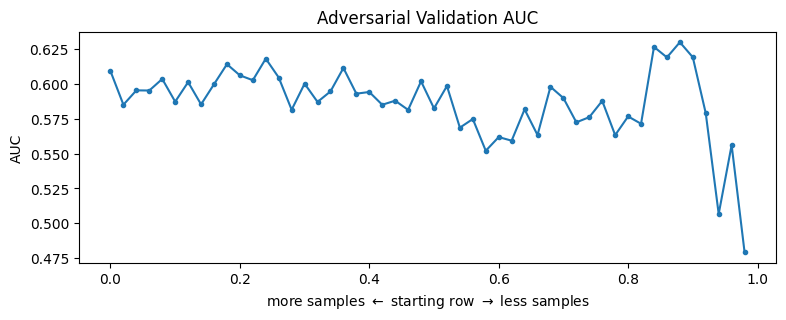

4949

In [28]:

# from xgboost import XGBClassifier
# from sklearn.model_selection import cross_val_score, StratifiedKFold

# def av(X1, X2):
#     X = pd.concat([X1, X2])
#     X = X.astype({c: 'category' for c in X.columns if X[c].dtype=='object'})
#     y = np.array([1]*len(X1)+[0]*len(X2))
#     return cross_val_score(
#         XGBClassifier(
#             enable_categorical=True,
#             n_jobs=4, random_state=0
#         ), X, y, n_jobs=1,
#         cv=StratifiedKFold(5, shuffle=True, random_state=0),
#         scoring='roc_auc'  
#     ).mean()


# start = np.linspace(0,1,50, endpoint=False)
# scores = []
# for r in start:
#     scores.append(av(train.iloc[int(r*len(train)):], test))

# plt.subplots(figsize=(9,3))
# plt.plot(start, scores, '.-')
# plt.xlabel(r'more samples $\leftarrow\quad$ starting row $\quad\rightarrow$ less samples')
# plt.title('Adversarial Validation AUC')
# plt.show()




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold


train_av = train.copy()
test_av = test.copy()

# Drop non-feature columns
train_av = train_av.drop(columns=['ID_code', 'target'], errors='ignore')
test_av = test_av.drop(columns=['ID_code'], errors='ignore')

def av(X1, X2):
    X = pd.concat([X1, X2], ignore_index=True)
    y = np.array([1]*len(X1) + [0]*len(X2))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    
    return cross_val_score(
        XGBClassifier(
            n_jobs=4,           # threads per model
            tree_method='hist', # faster numeric training
            random_state=0
        ),
        X, y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1  # parallelize folds
    ).mean()

# Define the starting fractions
start = np.linspace(0, 1, 50, endpoint=False)
scores = []

for r in start:
    # Take a subset of train starting at row int(r * len(train))
    train_subset = train_av.iloc[int(r*len(train_av)):]
    scores.append(av(train_subset, test_av))

# Plot
plt.subplots(figsize=(9,3))
plt.plot(start, scores, '.-')
plt.xlabel(r'more samples $\leftarrow$ starting row $\rightarrow$ less samples')
plt.ylabel('AUC')
plt.title('Adversarial Validation AUC')
plt.show()


# Cleanup
del train_av, test_av
gc.collect()
